<a href="https://colab.research.google.com/github/ememAFO/wildfire-detection/blob/main/WildFire_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision matplotlib numpy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import os
# import shutil
# from sklearn.model_selection import train_test_split

# # Define paths
# dataset_dir = '/content/drive/MyDrive/WildFires'  # Root folder containing 'fires' and 'non-fires'
# output_dir = '/content/drive/MyDrive/WildFires/Splits'  # Folder to save the split dataset

# # Create output directories
# os.makedirs(os.path.join(output_dir, 'train', 'fire_images'), exist_ok=True)
# os.makedirs(os.path.join(output_dir, 'train', 'non_fire_images'), exist_ok=True)
# os.makedirs(os.path.join(output_dir, 'val', 'fire_images'), exist_ok=True)
# os.makedirs(os.path.join(output_dir, 'val', 'non_fire_images'), exist_ok=True)
# os.makedirs(os.path.join(output_dir, 'test', 'fire_images'), exist_ok=True)
# os.makedirs(os.path.join(output_dir, 'test', 'non_fire_images'), exist_ok=True)

# # Function to split and copy images
# def split_dataset(class_name, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
#     class_dir = os.path.join(dataset_dir, class_name)
#     images = os.listdir(class_dir)
#     train_images, test_images = train_test_split(images, test_size=1 - train_ratio, random_state=42)
#     val_images, test_images = train_test_split(test_images, test_size=test_ratio/(test_ratio + val_ratio), random_state=42)

#     # Copy images to respective folders
#     for img in train_images:
#         shutil.copy(os.path.join(class_dir, img), os.path.join(output_dir, 'train', class_name, img))
#     for img in val_images:
#         shutil.copy(os.path.join(class_dir, img), os.path.join(output_dir, 'val', class_name, img))
#     for img in test_images:
#         shutil.copy(os.path.join(class_dir, img), os.path.join(output_dir, 'test', class_name, img))

# # Split 'fires' and 'non-fires' folders
# split_dataset('fire_images')
# split_dataset('non_fire_images')

# print("Dataset split completed!")

#**1. Image Resizing (224x224)**
##**Justification**

Most deep learning models, particularly CNNs, require a fixed input size. Many pre-trained models, including ResNet, AlexNet, and EfficientNet, are optimized for 224×224 pixel images as used in ImageNet training (Deng et al., 2009). Resizing ensures compatibility with pre-trained architectures and reduces computational cost while maintaining important image features.

Reference

Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K., & Fei-Fei, L. (2009). ImageNet: A Large-Scale Hierarchical Image Database. IEEE CVPR.

#**3. Normalization**
##**Justification**

CNNs perform better when pixel intensity values are normalized to a standard range, such as mean = 0, standard deviation = 1. This improves gradient flow, accelerates convergence, and prevents exploding/vanishing gradients (LeCun et al., 1998).


Reference

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-Based Learning Applied to Document Recognition. IEEE.




In [ ]:
import warnings
warnings.filterwarnings('ignore')

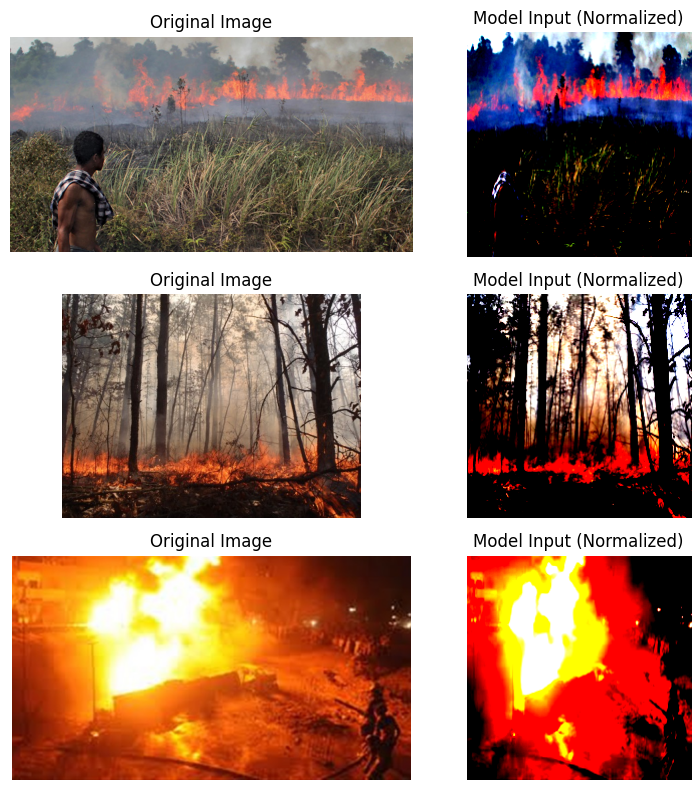

In [ ]:
import os
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader
from PIL import Image

# Define paths
output_dir = "/content/drive/MyDrive/Splits"

# Define transformations (used for training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor(),           # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize
])

# Load datasets
train_dataset = datasets.ImageFolder(root=os.path.join(output_dir, 'train'), transform=transform)
val_dataset = datasets.ImageFolder(root=os.path.join(output_dir, 'val'), transform=transform)
test_dataset = datasets.ImageFolder(root=os.path.join(output_dir, 'test'), transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Function to visualize original and preprocessed images
def visualize_preprocessing(dataset, num_images=3):
    fig, axes = plt.subplots(num_images, 2, figsize=(8, 8))

    for i in range(num_images):
        # Load original image
        img_path = dataset.imgs[i][0]  # Get image path
        original_img = Image.open(img_path).convert("RGB")

        # Apply transformations
        transformed_img = transform(original_img)

        # Convert tensor to numpy for visualization
        transformed_img = transformed_img.permute(1, 2, 0).numpy()  # Rearrange dimensions

        # Plot original image
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        # Plot transformed image (model input)
        axes[i, 1].imshow(transformed_img)
        axes[i, 1].set_title("Model Input (Normalized)")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

# Run visualization
visualize_preprocessing(train_dataset)


In [ ]:
import torchvision.models as models
import torch.nn as nn
import warnings
warnings.filterwarnings("ignore")

# Function to load and modify a pre-trained model
def get_model(model_name, num_classes=2):
    if model_name == 'resnet18':
        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)  # Modify the final layer
    elif model_name == 'resnet50':
        model = models.resnet50(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)  # Modify the final layer
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)  # Modify the final layer
    elif model_name == 'alexnet':
        model = models.alexnet(pretrained=True)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)  # Modify the final layer
    elif model_name == 'vgg16':
        model = models.vgg16(pretrained=True)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)  # Modify the final layer
    elif model_name == 'vgg19':
        model = models.vgg19(pretrained=True)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)  # Modify the final layer
    elif model_name == 'mobilenet_v2':
        model = models.mobilenet_v2(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)  # Modify the final layer
    else:
        raise ValueError("Model not supported.")
    return model

# Load models
resnet18 = get_model('resnet18')
resnet50 = get_model('resnet50')
efficientnet_b0 = get_model('efficientnet_b0')
alexnet = get_model('alexnet')
vgg16 = get_model('vgg16')
vgg19 = get_model('vgg19')
mobilenet_v2 = get_model('mobilenet_v2')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:02<00:00, 104MB/s] 
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 132MB/s]
Downloading: "https://download.pytorch.org/m

#**2. Choice of Models (AlexNet, ResNet, VGG, EfficientNet, etc.)**

#**Justification**

**AlexNet (Krizhevsky et al., 2012)**
 -One of the first deep CNNs to achieve breakthrough performance in ImageNet classification. Chosen for historical comparison.

**ResNet (He et al., 2016)**
-Introduces residual connections, addressing vanishing gradient issues in deep networks.

**VGG-16/19 (Simonyan & Zisserman, 2015) ***- Uses deep layers with small convolution filters, effective for texture-rich images like wildfire imagery.

**EfficientNet (Tan & Le, 2019) *** - Optimized for high accuracy with fewer parameters, making it efficient for real-time applications.

**MobileNet (Howard et al., 2017)** - Designed for mobile and embedded applications, useful for real-time wildfire detection.

**References**

Krizhevsky, A., Sutskever, I., & Hinton, G. (2012). ImageNet Classification with Deep Convolutional Neural Networks. NeurIPS.

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep Residual Learning for Image Recognition. IEEE CVPR.

Simonyan, K., & Zisserman, A. (2015). Very Deep Convolutional Networks for Large-Scale Image Recognition. ICLR.

Tan, M., & Le, Q. (2019). EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks. ICML.
Howard, A. G., et al. (2017).

 MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications. arXiv.

In [ ]:
import torch.optim as optim
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, model_name='Model'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []
    best_accuracy = 0.0
    model_save_path = os.path.join(output_dir, f'{model_name}.pth')  # Save in dataset folder

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        # Evaluate on validation set
        val_accuracy = evaluate_model(model, val_loader)
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')

        # Save best model
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), model_save_path)
            print(f'Saved best model: {model_save_path}')



    # Plot training and validation curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Training Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name}- Validation Accuracy')
    plt.legend()

    plt.show()

    return train_losses, val_accuracies


# Evaluation function
def evaluate_model(model, val_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Validation Accuracy: {accuracy:.2f}%')
    return accuracy

Training ResNet-18...


Epoch 1/10: 100%|██████████| 21/21 [09:04<00:00, 25.95s/it]


Validation Accuracy: 84.12%
Epoch 1, Loss: 0.2798, Validation Accuracy: 84.12%
Saved best model: /content/drive/MyDrive/Splits/ResNet-18.pth


Epoch 2/10: 100%|██████████| 21/21 [00:25<00:00,  1.20s/it]


Validation Accuracy: 91.42%
Epoch 2, Loss: 0.1373, Validation Accuracy: 91.42%
Saved best model: /content/drive/MyDrive/Splits/ResNet-18.pth


...

Validation Accuracy: 97.42%
Epoch 8, Loss: 0.0408, Validation Accuracy: 97.42%


Epoch 9/10: 100%|██████████| 21/21 [00:24<00:00,  1.14s/it]


Validation Accuracy: 97.00%
Epoch 9, Loss: 0.0304, Validation Accuracy: 97.00%


Epoch 10/10: 100%|██████████| 21/21 [00:24<00:00,  1.17s/it]


Validation Accuracy: 98.28%
Epoch 10, Loss: 0.0403, Validation Accuracy: 98.28%
Saved best model: /content/drive/MyDrive/Splits/ResNet-18.pth


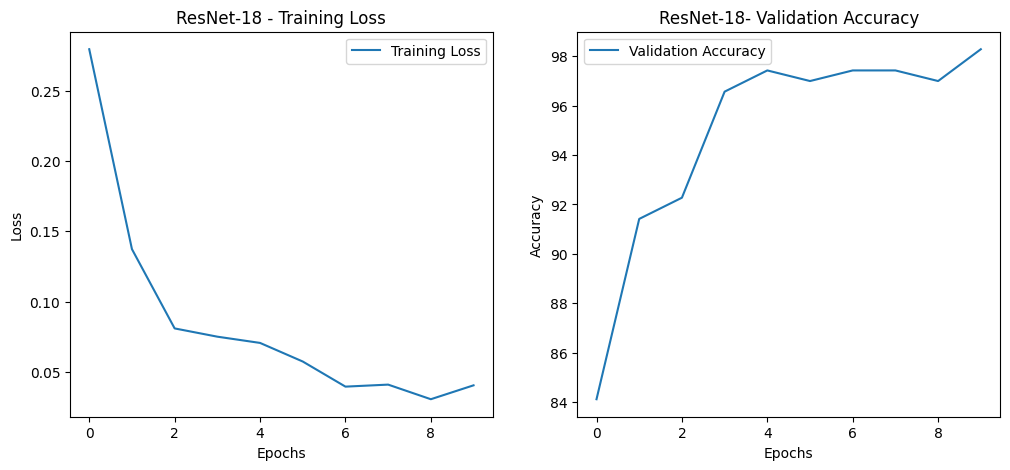

In [ ]:
# Train ResNet-18
print("Training ResNet-18...")
resnet18_loss, resnet18_acc = train_model(resnet18, train_loader, val_loader, epochs=10, model_name='ResNet-18')

Training ResNet-50...


Epoch 1/10: 100%|██████████| 21/21 [00:31<00:00,  1.50s/it]


Validation Accuracy: 39.91%
Epoch 1, Loss: 0.3052, Validation Accuracy: 39.91%
Saved best model: /content/drive/MyDrive/Splits/ResNet-50.pth


Epoch 2/10: 100%|██████████| 21/21 [00:30<00:00,  1.44s/it]


Validation Accuracy: 94.85%
Epoch 2, Loss: 0.1140, Validation Accuracy: 94.85%
Saved best model: /content/drive/MyDrive/Splits/ResNet-50.pth


...

Validation Accuracy: 97.85%
Epoch 8, Loss: 0.0545, Validation Accuracy: 97.85%
Saved best model: /content/drive/MyDrive/Splits/ResNet-50.pth


Epoch 9/10: 100%|██████████| 21/21 [00:29<00:00,  1.41s/it]


Validation Accuracy: 98.28%
Epoch 9, Loss: 0.0367, Validation Accuracy: 98.28%
Saved best model: /content/drive/MyDrive/Splits/ResNet-50.pth


Epoch 10/10: 100%|██████████| 21/21 [00:29<00:00,  1.40s/it]


Validation Accuracy: 96.14%
Epoch 10, Loss: 0.0492, Validation Accuracy: 96.14%


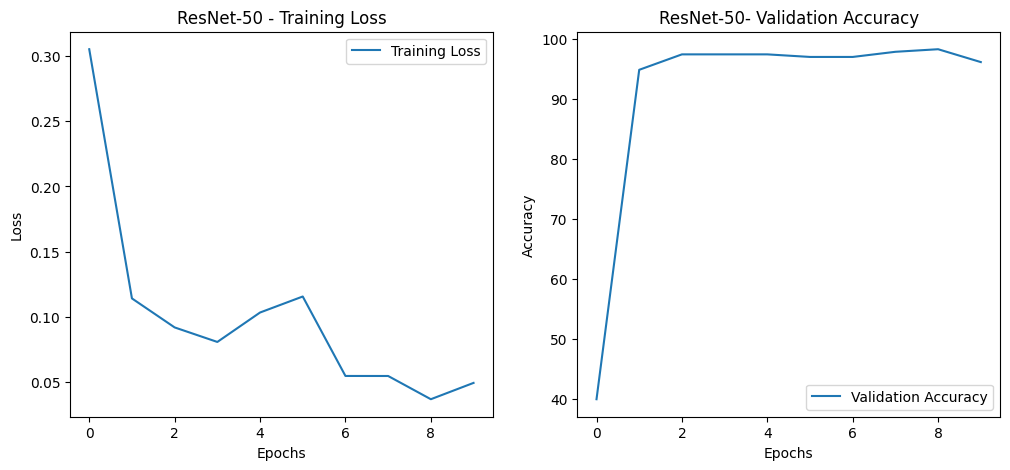

In [ ]:
# Train ResNet-50
print("Training ResNet-50...")
resnet50_loss, resnet50_acc = train_model(resnet50, train_loader, val_loader, epochs=10, model_name='ResNet-50')

Training EfficientNet-B0...


Epoch 1/10: 100%|██████████| 21/21 [00:25<00:00,  1.24s/it]


Validation Accuracy: 98.28%
Epoch 1, Loss: 0.1819, Validation Accuracy: 98.28%
Saved best model: /content/drive/MyDrive/Splits/EfficientNet_B0.pth


Epoch 2/10: 100%|██████████| 21/21 [00:25<00:00,  1.23s/it]


Validation Accuracy: 99.57%
Epoch 2, Loss: 0.0299, Validation Accuracy: 99.57%
Saved best model: /content/drive/MyDrive/Splits/EfficientNet_B0.pth


...

Validation Accuracy: 99.14%
Epoch 8, Loss: 0.0038, Validation Accuracy: 99.14%


Epoch 9/10: 100%|██████████| 21/21 [00:25<00:00,  1.22s/it]


Validation Accuracy: 99.14%
Epoch 9, Loss: 0.0140, Validation Accuracy: 99.14%


Epoch 10/10: 100%|██████████| 21/21 [00:25<00:00,  1.21s/it]


Validation Accuracy: 98.71%
Epoch 10, Loss: 0.0092, Validation Accuracy: 98.71%


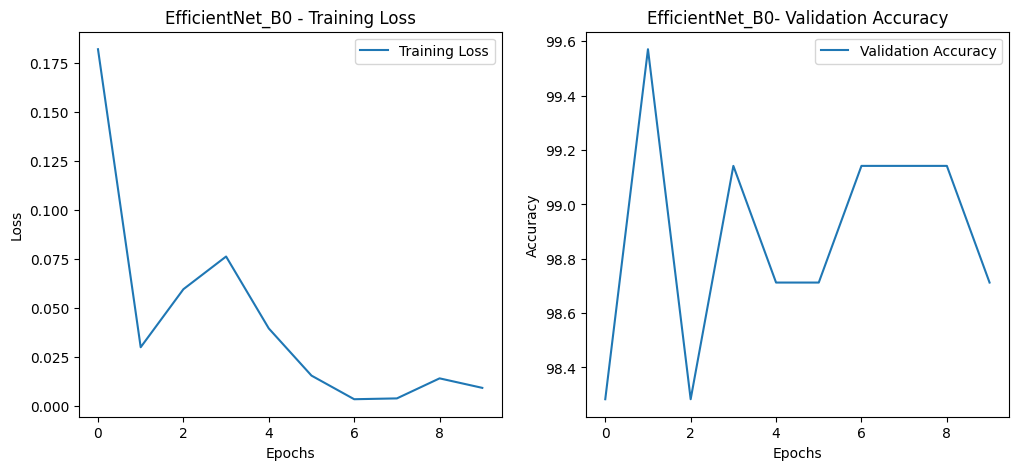

In [ ]:
# Train EfficientNet-B0
print("Training EfficientNet-B0...")
efficientnet_b0_loss, efficientnet_b0_acc = train_model(efficientnet_b0, train_loader, val_loader, epochs=10 , model_name='EfficientNet_B0')

Training AlexNet...


Epoch 1/10: 100%|██████████| 21/21 [00:23<00:00,  1.12s/it]


Validation Accuracy: 87.98%
Epoch 1, Loss: 1.1477, Validation Accuracy: 87.98%
Saved best model: /content/drive/MyDrive/Splits/AlexNet.pth


Epoch 2/10: 100%|██████████| 21/21 [00:23<00:00,  1.14s/it]


Validation Accuracy: 43.78%
Epoch 2, Loss: 0.5552, Validation Accuracy: 43.78%


...

Validation Accuracy: 69.96%
Epoch 8, Loss: 1.2162, Validation Accuracy: 69.96%


Epoch 9/10: 100%|██████████| 21/21 [00:23<00:00,  1.11s/it]


Validation Accuracy: 69.96%
Epoch 9, Loss: 1.0010, Validation Accuracy: 69.96%


Epoch 10/10: 100%|██████████| 21/21 [00:23<00:00,  1.12s/it]


Validation Accuracy: 69.96%
Epoch 10, Loss: 0.6374, Validation Accuracy: 69.96%


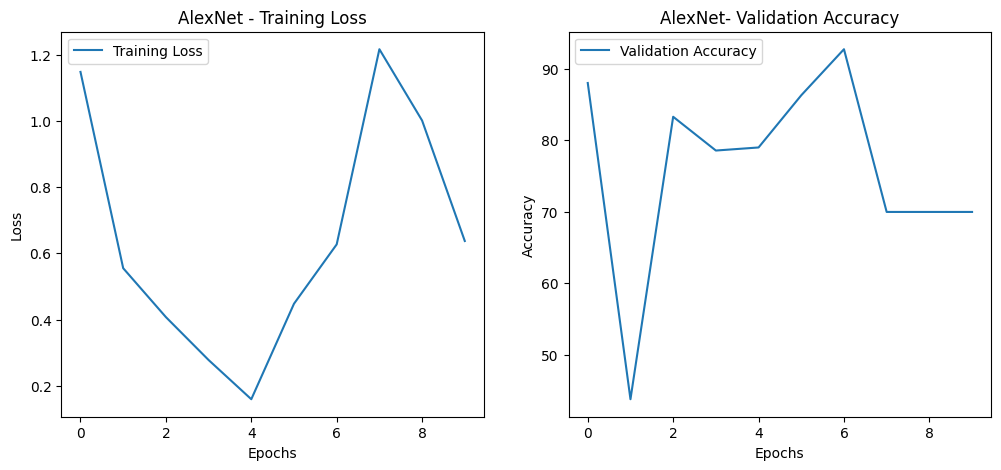

In [ ]:
# Train and evaluate AlexNet
print("Training AlexNet...")
alexnet_loss, alexnet_acc = train_model(alexnet, train_loader, val_loader, epochs=10, model_name='AlexNet')

Training VGG-16...


Epoch 1/10: 100%|██████████| 21/21 [00:31<00:00,  1.52s/it]


Validation Accuracy: 69.96%
Epoch 1, Loss: 1.0834, Validation Accuracy: 69.96%
Saved best model: /content/drive/MyDrive/Splits/VGG-16.pth


Epoch 2/10: 100%|██████████| 21/21 [00:34<00:00,  1.62s/it]


Validation Accuracy: 85.41%
Epoch 2, Loss: 0.5049, Validation Accuracy: 85.41%
Saved best model: /content/drive/MyDrive/Splits/VGG-16.pth


...

Validation Accuracy: 93.56%
Epoch 8, Loss: 0.1773, Validation Accuracy: 93.56%
Saved best model: /content/drive/MyDrive/Splits/VGG-16.pth


Epoch 9/10: 100%|██████████| 21/21 [00:33<00:00,  1.58s/it]


Validation Accuracy: 97.85%
Epoch 9, Loss: 0.1347, Validation Accuracy: 97.85%
Saved best model: /content/drive/MyDrive/Splits/VGG-16.pth


Epoch 10/10: 100%|██████████| 21/21 [00:32<00:00,  1.55s/it]


Validation Accuracy: 95.71%
Epoch 10, Loss: 0.0837, Validation Accuracy: 95.71%


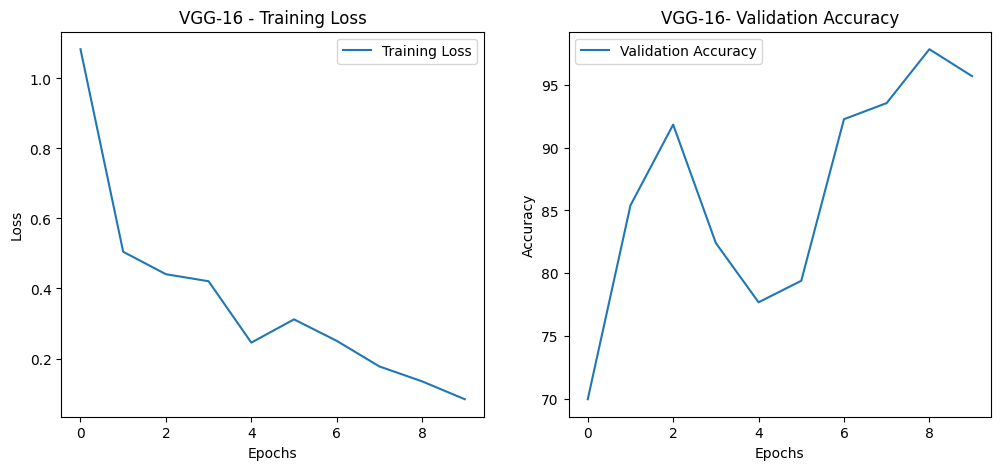

In [ ]:
# Train and evaluate VGG-16
print("Training VGG-16...")
vgg16_loss, vgg16_acc=train_model(vgg16, train_loader, val_loader, epochs=10, model_name='VGG-16')

Training VGG-19...


Epoch 1/10: 100%|██████████| 21/21 [00:33<00:00,  1.59s/it]


Validation Accuracy: 69.96%
Epoch 1, Loss: 1.7457, Validation Accuracy: 69.96%
Saved best model: /content/drive/MyDrive/Splits/VGG-19.pth


Epoch 2/10: 100%|██████████| 21/21 [00:35<00:00,  1.67s/it]


Validation Accuracy: 82.83%
Epoch 2, Loss: 0.5968, Validation Accuracy: 82.83%
Saved best model: /content/drive/MyDrive/Splits/VGG-19.pth


...

Validation Accuracy: 69.96%
Epoch 8, Loss: 1.0831, Validation Accuracy: 69.96%


Epoch 9/10: 100%|██████████| 21/21 [00:33<00:00,  1.58s/it]


Validation Accuracy: 69.96%
Epoch 9, Loss: 0.6393, Validation Accuracy: 69.96%


Epoch 10/10: 100%|██████████| 21/21 [00:33<00:00,  1.58s/it]


Validation Accuracy: 69.96%
Epoch 10, Loss: 0.6341, Validation Accuracy: 69.96%


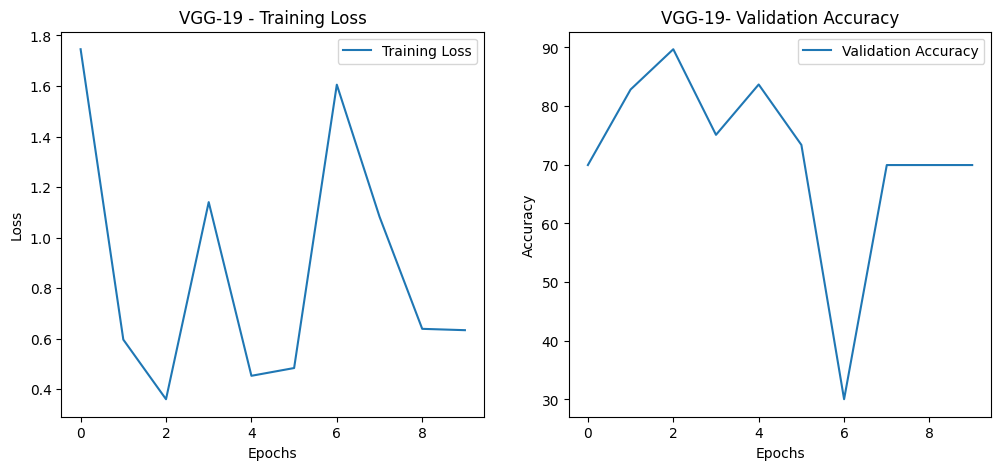

In [ ]:
# Train and evaluate VGG-19
print("Training VGG-19...")
vgg19_loss, vgg19_acc = train_model(vgg19, train_loader, val_loader, epochs=10, model_name='VGG-19')

Training MobileNet_V2...


Epoch 1/10: 100%|██████████| 21/21 [00:23<00:00,  1.14s/it]


Validation Accuracy: 96.57%
Epoch 1, Loss: 0.2052, Validation Accuracy: 96.57%
Saved best model: /content/drive/MyDrive/Splits/MobileNet_V2.pth


Epoch 2/10: 100%|██████████| 21/21 [00:24<00:00,  1.14s/it]


Validation Accuracy: 99.14%
Epoch 2, Loss: 0.0522, Validation Accuracy: 99.14%
Saved best model: /content/drive/MyDrive/Splits/MobileNet_V2.pth


...

Validation Accuracy: 99.14%
Epoch 8, Loss: 0.0159, Validation Accuracy: 99.14%


Epoch 9/10: 100%|██████████| 21/21 [00:25<00:00,  1.21s/it]


Validation Accuracy: 99.14%
Epoch 9, Loss: 0.0365, Validation Accuracy: 99.14%


Epoch 10/10: 100%|██████████| 21/21 [00:23<00:00,  1.12s/it]


Validation Accuracy: 96.57%
Epoch 10, Loss: 0.0377, Validation Accuracy: 96.57%


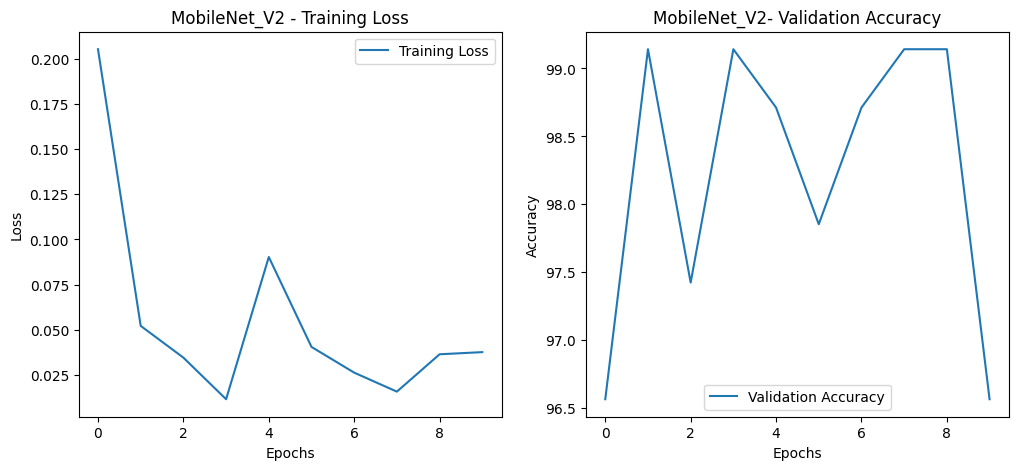

In [ ]:
# Train and evaluate MobileNet_V2
print("Training MobileNet_V2...")
mobilenet_v2_loss, mobilenet_v2_acc = train_model(mobilenet_v2, train_loader, val_loader, epochs=10, model_name='MobileNet_V2')

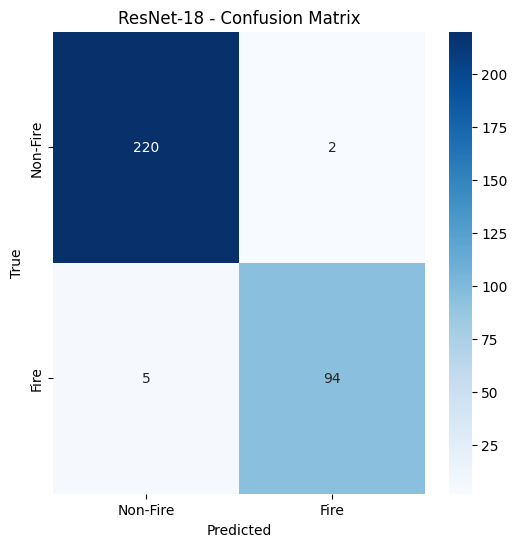

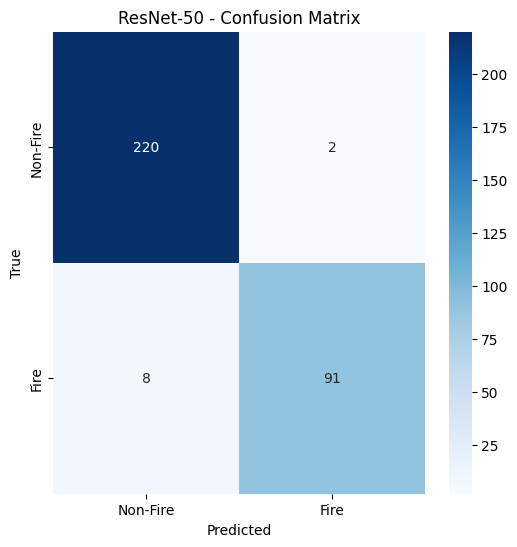

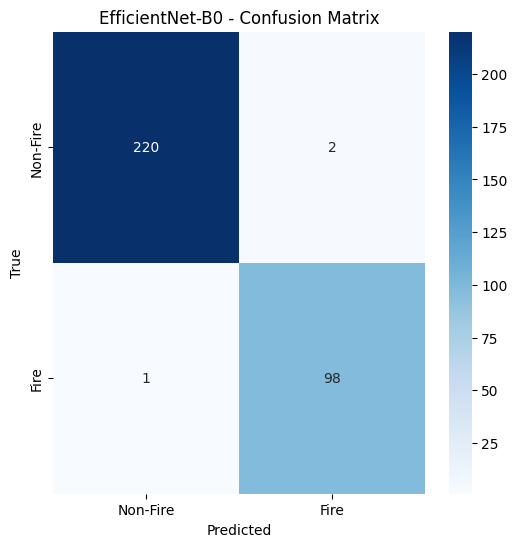

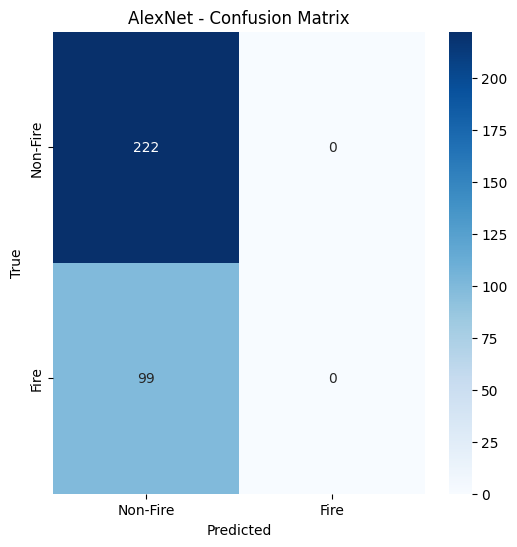

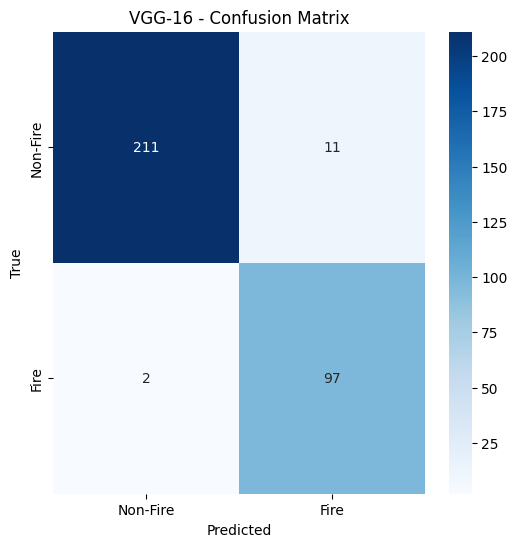

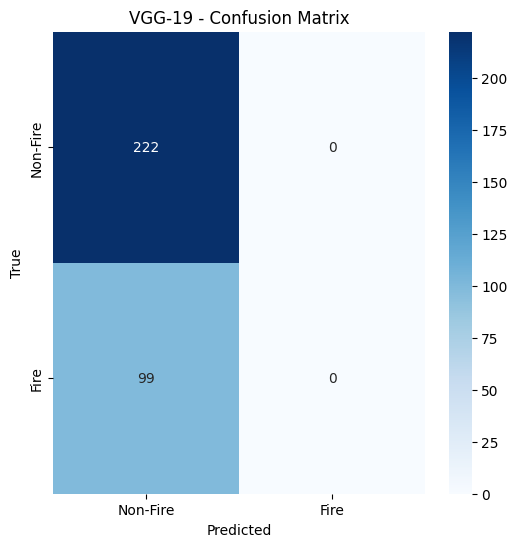

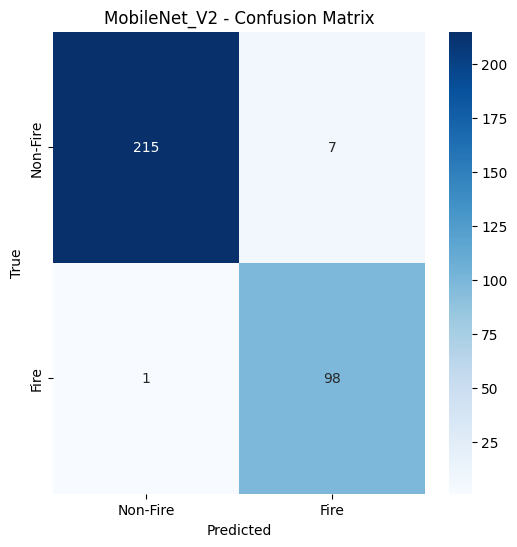

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

def plot_confusion_matrix(model, test_loader, model_name='Model'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Fire', 'Fire'], yticklabels=['Non-Fire', 'Fire'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

# Plot confusion matrices
plot_confusion_matrix(resnet18, test_loader, model_name='ResNet-18')
plot_confusion_matrix(resnet50, test_loader, model_name='ResNet-50')
plot_confusion_matrix(efficientnet_b0, test_loader, model_name='EfficientNet-B0')
plot_confusion_matrix(alexnet, test_loader, model_name='AlexNet')
plot_confusion_matrix(vgg16, test_loader, model_name='VGG-16')
plot_confusion_matrix(vgg19, test_loader, model_name='VGG-19')
plot_confusion_matrix(mobilenet_v2, test_loader, model_name='MobileNet_V2')

In [ ]:
from sklearn.metrics import classification_report

def generate_classification_report(model, test_loader, model_name ='Model'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    print(f'{model_name} - Classification Report:')
    print(classification_report(all_labels, all_preds, target_names=['fire_images', 'non_fire_images']))

# Generate classification reports
generate_classification_report(resnet18, test_loader, model_name='ResNet-18')
generate_classification_report(resnet50, test_loader, model_name='ResNet-50')
generate_classification_report(efficientnet_b0, test_loader, model_name='EfficientNet-B0')
generate_classification_report(alexnet, test_loader, model_name='AlexNet')
generate_classification_report(vgg16, test_loader, model_name='VGG-16')
generate_classification_report(vgg19, test_loader, model_name='VGG-19')
generate_classification_report(mobilenet_v2, test_loader, model_name='MobileNet_V2')

ResNet-18 - Classification Report:
                 precision    recall  f1-score   support

    fire_images       0.98      0.99      0.98       222
non_fire_images       0.98      0.95      0.96        99

       accuracy                           0.98       321
      macro avg       0.98      0.97      0.97       321
   weighted avg       0.98      0.98      0.98       321

ResNet-50 - Classification Report:
                 precision    recall  f1-score   support

    fire_images       0.96      0.99      0.98       222
non_fire_images       0.98      0.92      0.95        99

       accuracy                           0.97       321
      macro avg       0.97      0.96      0.96       321
   weighted avg       0.97      0.97      0.97       321

EfficientNet-B0 - Classification Report:
                 precision    recall  f1-score   support

    fire_images       1.00      0.99      0.99       222
non_fire_images       0.98      0.99      0.98        99

       accuracy           

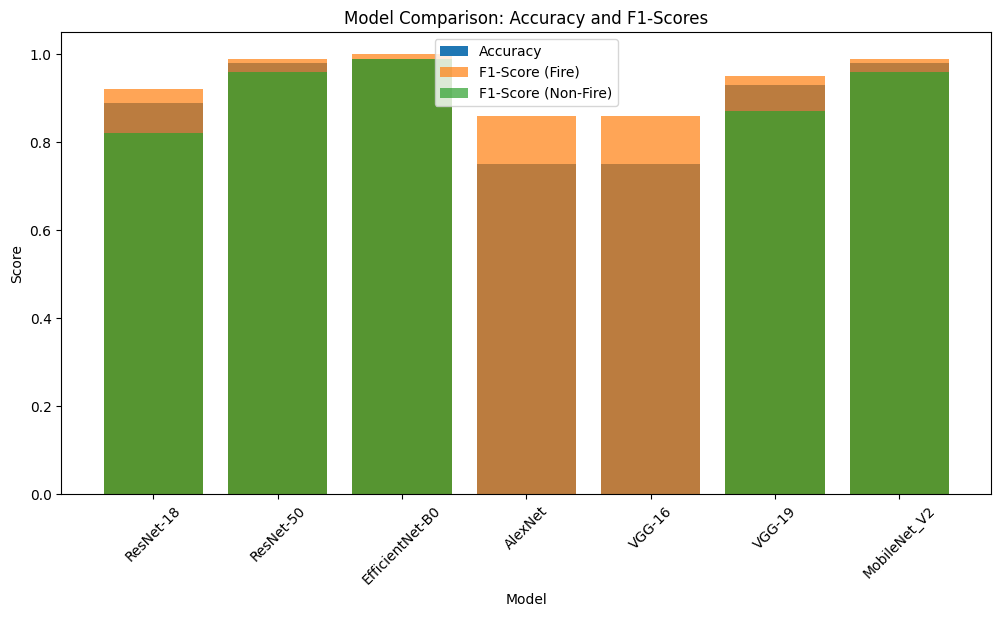

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Data for visualization
data = {
    'Model': ['ResNet-18', 'ResNet-50', 'EfficientNet-B0', 'AlexNet', 'VGG-16', 'VGG-19', 'MobileNet_V2'],
    'Accuracy': [0.89, 0.98, 0.99, 0.75, 0.75, 0.93, 0.98],
    'F1-Score (Fire)': [0.92, 0.99, 1.00, 0.86, 0.86, 0.95, 0.99],
    'F1-Score (Non-Fire)': [0.82, 0.96, 0.99, 0.00, 0.00, 0.87, 0.96]
}

df = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(df['Model'], df['Accuracy'], label='Accuracy')
plt.bar(df['Model'], df['F1-Score (Fire)'], label='F1-Score (Fire)', alpha=0.7)
plt.bar(df['Model'], df['F1-Score (Non-Fire)'], label='F1-Score (Non-Fire)', alpha=0.7)
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Comparison: Accuracy and F1-Scores')
plt.legend()
plt.xticks(rotation=45)
plt.show()

#**Novel-Architecture (Meta-Learner Logistic Regression- All the Finetuned-Models )**

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# Define device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model paths
model_paths = {
    "resnet18": "/content/drive/MyDrive/Splits/ResNet-18.pth",
    "resnet50": "/content/drive/MyDrive/Splits/ResNet-50.pth",
    "efficientnet_b0": "/content/drive/MyDrive/Splits/EfficientNet_B0.pth",
    "alexnet": "/content/drive/MyDrive/Splits/AlexNet.pth",
    "vgg16": "/content/drive/MyDrive/Splits/VGG-16.pth",
    "vgg19": "/content/drive/MyDrive/Splits/VGG-19.pth",
    "mobilenet_v2": "/content/drive/MyDrive/Splits/MobileNet_V2.pth"
}

# Function to initialize models dynamically
def load_model(model_name, path):
    model = getattr(models, model_name)(pretrained=False)
    if "classifier" in dir(model):
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 2)  # Modify classifier for binary classification
    else:
        model.fc = nn.Linear(model.fc.in_features, 2)  # Modify fully connected layer

    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

# Load all models
loaded_models = {name: load_model(name, path) for name, path in model_paths.items()}


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
def get_model_outputs(models, dataloader):
    X, y = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            model_preds = []

            for model in models.values():
                preds = torch.softmax(model(inputs), dim=1).cpu().numpy()
                model_preds.append(preds)

            combined_features = np.hstack(model_preds)  # Flatten predictions
            X.append(combined_features)
            y.append(labels.cpu().numpy())

    return np.vstack(X), np.hstack(y)


In [ ]:
# Get training data for meta-learner
X_train, y_train = get_model_outputs(loaded_models, train_loader)
X_val, y_val = get_model_outputs(loaded_models, val_loader)

# Train meta-classifier
meta_clf = LogisticRegression()
meta_clf.fit(X_train, y_train)

# Evaluate
y_pred = meta_clf.predict(X_val)
print("Meta-Ensemble Classification Report:")
print(classification_report(y_val, y_pred))


Meta-Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       163
           1       1.00      0.99      0.99        70

    accuracy                           1.00       233
   macro avg       1.00      0.99      0.99       233
weighted avg       1.00      1.00      1.00       233



**Training Without Normalization of Images**

In [ ]:
# Define transformation WITHOUT normalization (Only resizing)
transform_no_norm = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 224x224
    transforms.ToTensor()           # Convert images to PyTorch tensors (no normalization)
])

# Load datasets without normalization
train_dataset_no_norm = datasets.ImageFolder(root=os.path.join(output_dir, 'train'), transform=transform_no_norm)
val_dataset_no_norm = datasets.ImageFolder(root=os.path.join(output_dir, 'val'), transform=transform_no_norm)
test_dataset_no_norm = datasets.ImageFolder(root=os.path.join(output_dir, 'test'), transform=transform_no_norm)

# Create data loaders
train_loader_no_norm = DataLoader(train_dataset_no_norm, batch_size=32, shuffle=True)
val_loader_no_norm = DataLoader(val_dataset_no_norm, batch_size=32, shuffle=False)
test_loader_no_norm = DataLoader(test_dataset_no_norm, batch_size=32, shuffle=False)


In [ ]:
import torch.optim as optim
import torch.nn as nn
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

# Function to train models
def train_model_no_norm(model, train_loader, val_loader, epochs=10, lr=0.001, model_name='Model'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_accuracies = []
    best_accuracy = 0.0
    model_save_path = os.path.join(output_dir, f'{model_name}_NoNorm.pth')  # Save model without normalization

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)

        # Evaluate on validation set
        val_accuracy = evaluate_model(model, val_loader)
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')

        # Save best model
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            torch.save(model.state_dict(), model_save_path)
            print(f'Saved best model: {model_save_path}')

    # Plot training and validation curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Training Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Validation Accuracy')
    plt.legend()

    plt.show()

    return train_losses, val_accuracies

# Function to evaluate models
def evaluate_model(model, val_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


Training ResNet-18...


Epoch 1/10: 100%|██████████| 21/21 [00:24<00:00,  1.18s/it]


Epoch 1, Loss: 0.1930, Validation Accuracy: 86.70%
Saved best model: /content/drive/MyDrive/Splits/ResNet-18_NoNorm.pth


Epoch 2/10: 100%|██████████| 21/21 [00:24<00:00,  1.16s/it]


Epoch 2, Loss: 0.0660, Validation Accuracy: 95.71%
Saved best model: /content/drive/MyDrive/Splits/ResNet-18_NoNorm.pth


...

Epoch 8, Loss: 0.0741, Validation Accuracy: 95.71%


Epoch 9/10: 100%|██████████| 21/21 [00:23<00:00,  1.13s/it]


Epoch 9, Loss: 0.0412, Validation Accuracy: 96.57%


Epoch 10/10: 100%|██████████| 21/21 [00:24<00:00,  1.16s/it]


Epoch 10, Loss: 0.0434, Validation Accuracy: 95.71%


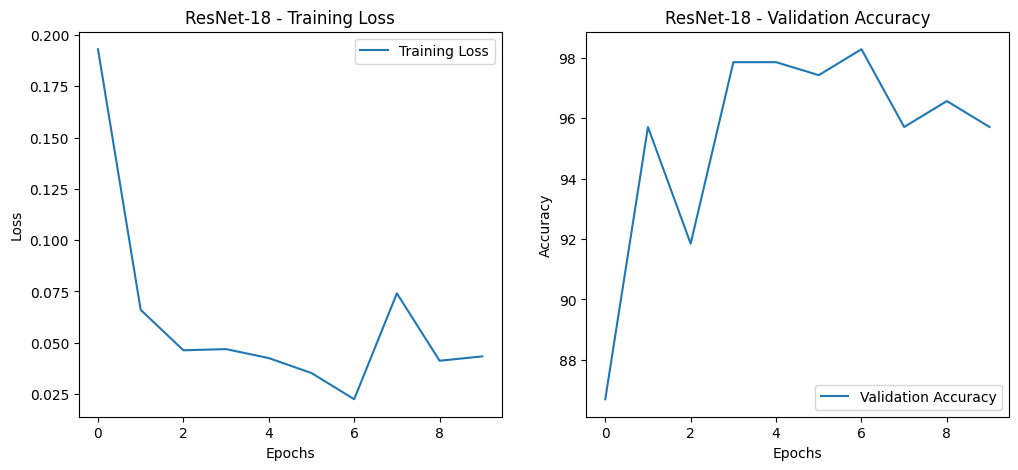

In [ ]:
# Train ResNet-18
print("Training ResNet-18...")
resnet18_loss, resnet18_acc = train_model_no_norm(resnet18, train_loader_no_norm, val_loader_no_norm, epochs=10, model_name='ResNet-18')

Training ResNet-50...


Epoch 1/10: 100%|██████████| 21/21 [00:28<00:00,  1.37s/it]


Epoch 1, Loss: 0.3745, Validation Accuracy: 89.70%
Saved best model: /content/drive/MyDrive/Splits/ResNet-50_NoNorm.pth


Epoch 2/10: 100%|██████████| 21/21 [00:28<00:00,  1.36s/it]


Epoch 2, Loss: 0.1475, Validation Accuracy: 94.85%
Saved best model: /content/drive/MyDrive/Splits/ResNet-50_NoNorm.pth


...

Epoch 8, Loss: 0.0406, Validation Accuracy: 97.85%


Epoch 9/10: 100%|██████████| 21/21 [00:28<00:00,  1.37s/it]


Epoch 9, Loss: 0.0320, Validation Accuracy: 98.28%


Epoch 10/10: 100%|██████████| 21/21 [00:28<00:00,  1.35s/it]


Epoch 10, Loss: 0.0236, Validation Accuracy: 97.00%


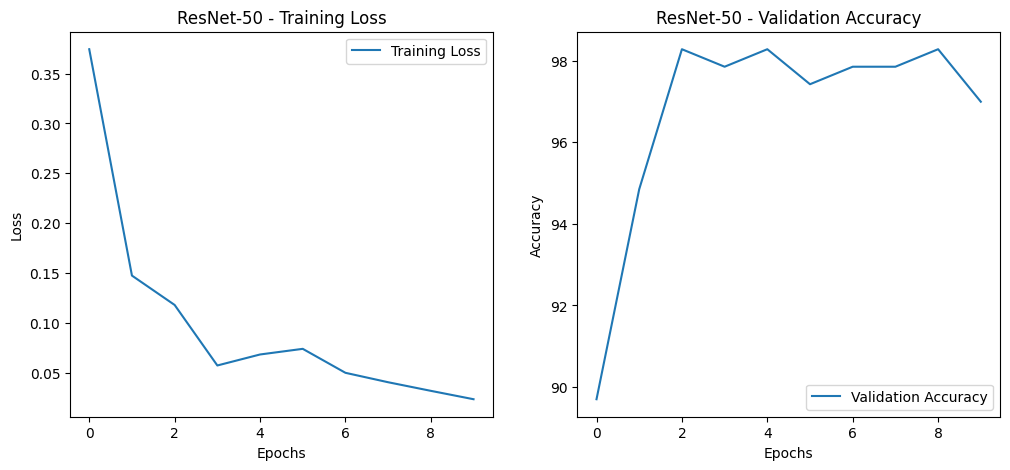

In [ ]:
# Train ResNet-18
print("Training ResNet-50...")
resnet18_loss, resnet18_acc = train_model_no_norm(resnet50, train_loader_no_norm, val_loader_no_norm, epochs=10, model_name='ResNet-50')

Training EfficientNet-B0... Without Normalization


Epoch 1/10: 100%|██████████| 21/21 [00:25<00:00,  1.21s/it]


Epoch 1, Loss: 0.1555, Validation Accuracy: 99.14%
Saved best model: /content/drive/MyDrive/Splits/EfficientNet_B0_NoNorm.pth


Epoch 2/10: 100%|██████████| 21/21 [00:25<00:00,  1.21s/it]


Epoch 2, Loss: 0.0927, Validation Accuracy: 98.71%


...

Epoch 8, Loss: 0.0382, Validation Accuracy: 98.71%


Epoch 9/10: 100%|██████████| 21/21 [00:25<00:00,  1.20s/it]


Epoch 9, Loss: 0.0218, Validation Accuracy: 98.71%


Epoch 10/10: 100%|██████████| 21/21 [00:25<00:00,  1.20s/it]


Epoch 10, Loss: 0.0206, Validation Accuracy: 96.57%


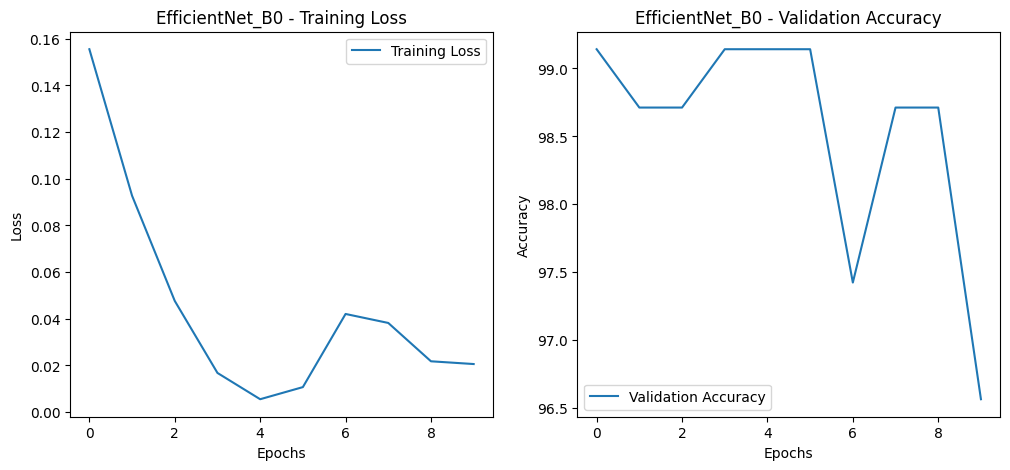

In [ ]:
# Train EfficientNet-B0
print("Training EfficientNet-B0... Without Normalization")
efficientnet_b0_loss, efficientnet_b0_acc = train_model_no_norm(efficientnet_b0, train_loader_no_norm, val_loader_no_norm, epochs=10 , model_name='EfficientNet_B0')


Training AlexNet Without Normalization...


Epoch 1/10: 100%|██████████| 21/21 [00:23<00:00,  1.13s/it]


Epoch 1, Loss: 1.3531, Validation Accuracy: 69.96%
Saved best model: /content/drive/MyDrive/Splits/AlexNet_NoNorm.pth


Epoch 2/10: 100%|██████████| 21/21 [00:24<00:00,  1.15s/it]


Epoch 2, Loss: 0.5422, Validation Accuracy: 82.40%
Saved best model: /content/drive/MyDrive/Splits/AlexNet_NoNorm.pth


...

Epoch 8, Loss: 0.4246, Validation Accuracy: 85.41%


Epoch 9/10: 100%|██████████| 21/21 [00:22<00:00,  1.07s/it]


Epoch 9, Loss: 0.3398, Validation Accuracy: 85.84%


Epoch 10/10: 100%|██████████| 21/21 [00:23<00:00,  1.14s/it]


Epoch 10, Loss: 0.2276, Validation Accuracy: 94.85%
Saved best model: /content/drive/MyDrive/Splits/AlexNet_NoNorm.pth


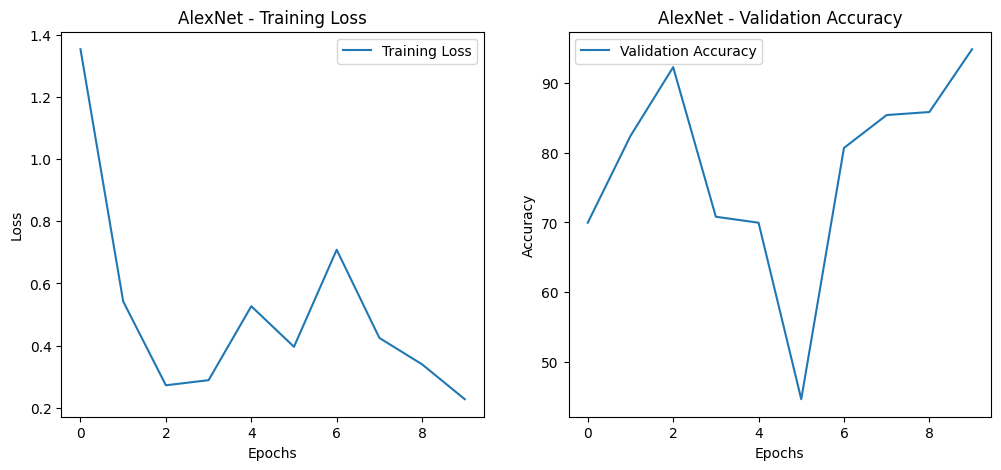

In [ ]:
# Train and evaluate AlexNet
print("Training AlexNet Without Normalization...")
alexnet_loss, alexnet_acc = train_model_no_norm(alexnet, train_loader_no_norm, val_loader_no_norm, epochs=10, model_name='AlexNet')


Training VGG-16 Without Normalization...


Epoch 1/10: 100%|██████████| 21/21 [00:32<00:00,  1.56s/it]


Epoch 1, Loss: 0.8451, Validation Accuracy: 76.39%
Saved best model: /content/drive/MyDrive/Splits/VGG-16_NoNorm.pth


Epoch 2/10: 100%|██████████| 21/21 [00:33<00:00,  1.59s/it]


Epoch 2, Loss: 0.4324, Validation Accuracy: 69.96%


...

Epoch 8, Loss: 0.6407, Validation Accuracy: 69.96%


Epoch 9/10: 100%|██████████| 21/21 [00:31<00:00,  1.49s/it]


Epoch 9, Loss: 0.6387, Validation Accuracy: 69.96%


Epoch 10/10: 100%|██████████| 21/21 [00:30<00:00,  1.47s/it]


Epoch 10, Loss: 0.6376, Validation Accuracy: 69.96%


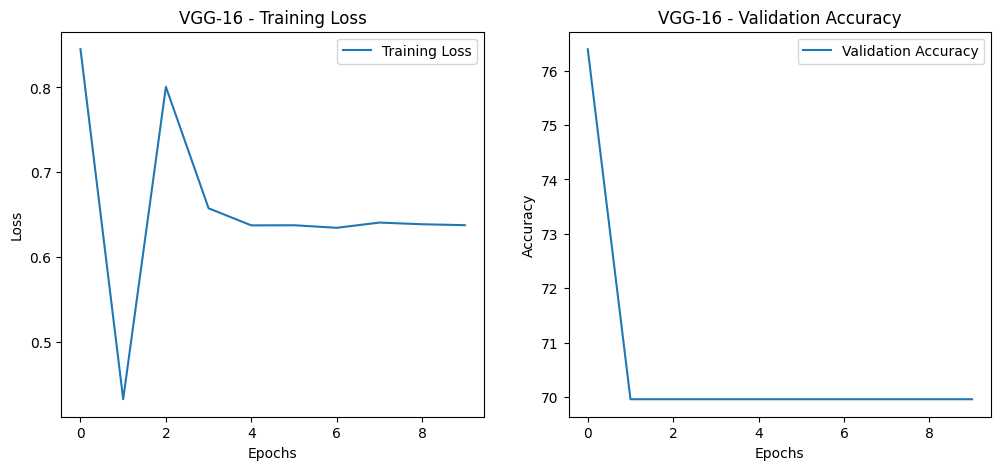

In [ ]:
# Train and evaluate VGG-16
print("Training VGG-16 Without Normalization...")
vgg16_loss, vgg16_acc=train_model_no_norm(vgg16, train_loader_no_norm, val_loader_no_norm, epochs=10, model_name='VGG-16')


Training VGG-19 without Normalization...


Epoch 1/10: 100%|██████████| 21/21 [00:32<00:00,  1.56s/it]


Epoch 1, Loss: 2.0386, Validation Accuracy: 69.96%
Saved best model: /content/drive/MyDrive/Splits/VGG-19_NoNorm.pth


Epoch 2/10: 100%|██████████| 21/21 [00:34<00:00,  1.64s/it]


Epoch 2, Loss: 0.8948, Validation Accuracy: 79.83%
Saved best model: /content/drive/MyDrive/Splits/VGG-19_NoNorm.pth


...

Epoch 8, Loss: 0.1644, Validation Accuracy: 90.13%


Epoch 9/10: 100%|██████████| 21/21 [00:33<00:00,  1.58s/it]


Epoch 9, Loss: 0.2835, Validation Accuracy: 87.55%


Epoch 10/10: 100%|██████████| 21/21 [00:34<00:00,  1.63s/it]


Epoch 10, Loss: 0.2644, Validation Accuracy: 79.40%


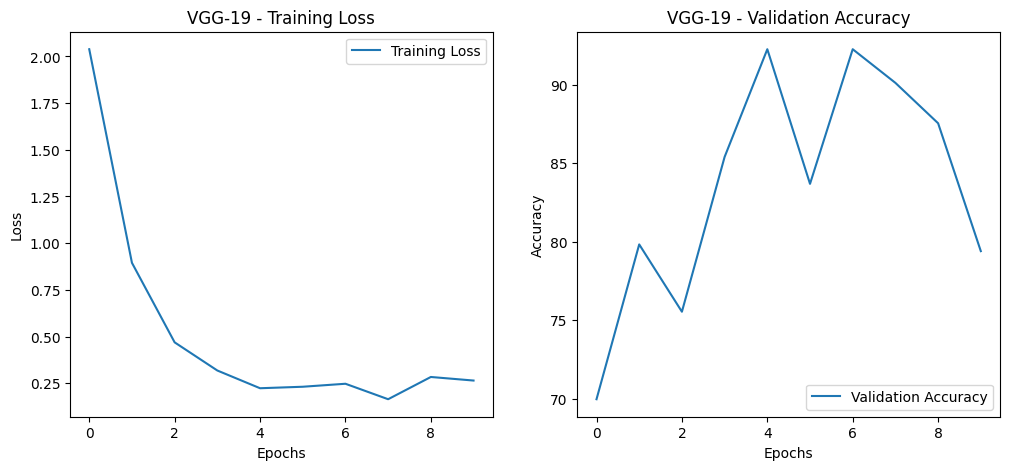

In [ ]:
# Train and evaluate VGG-19
print("Training VGG-19 without Normalization...")
vgg19_loss, vgg19_acc = train_model_no_norm(vgg19, train_loader_no_norm, val_loader_no_norm, epochs=10, model_name='VGG-19')


Training MobileNet_V2 Without Normalization...


Epoch 1/10: 100%|██████████| 21/21 [00:23<00:00,  1.14s/it]


Epoch 1, Loss: 0.1890, Validation Accuracy: 97.85%
Saved best model: /content/drive/MyDrive/Splits/MobileNet_V2_NoNorm.pth


Epoch 2/10: 100%|██████████| 21/21 [00:23<00:00,  1.10s/it]


Epoch 2, Loss: 0.1039, Validation Accuracy: 97.85%


...

Epoch 8, Loss: 0.0523, Validation Accuracy: 96.14%


Epoch 9/10: 100%|██████████| 21/21 [00:23<00:00,  1.12s/it]


Epoch 9, Loss: 0.0152, Validation Accuracy: 99.14%


Epoch 10/10: 100%|██████████| 21/21 [00:24<00:00,  1.17s/it]


Epoch 10, Loss: 0.0068, Validation Accuracy: 98.28%


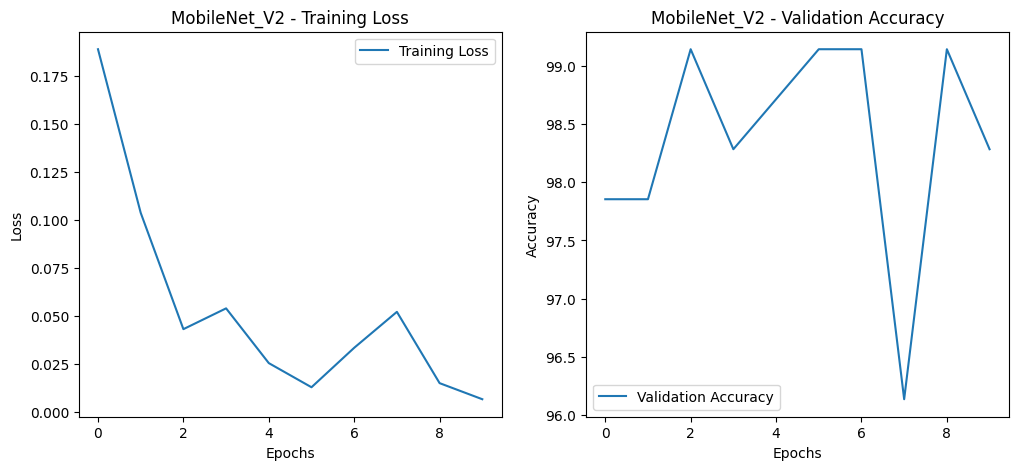

In [ ]:
# Train and evaluate MobileNet_V2
print("Training MobileNet_V2 Without Normalization...")
mobilenet_v2_loss, mobilenet_v2_acc = train_model_no_norm(mobilenet_v2, train_loader_no_norm, val_loader_no_norm, epochs=10, model_name='MobileNet_V2')


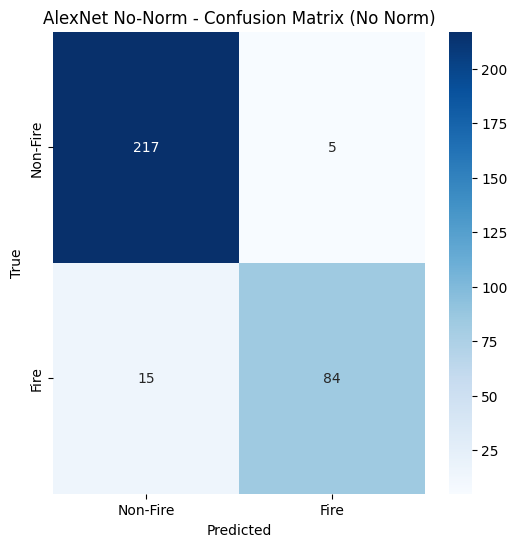

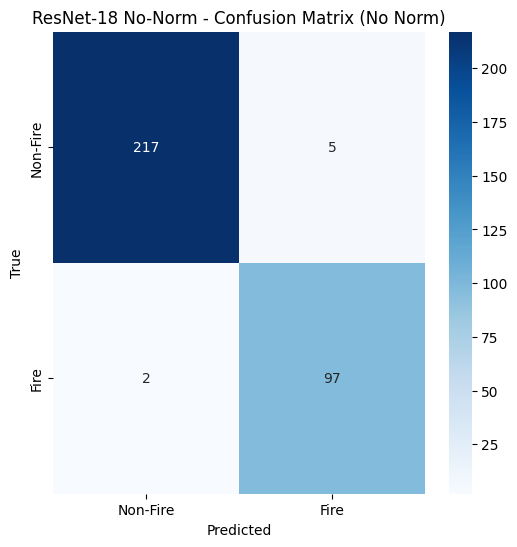

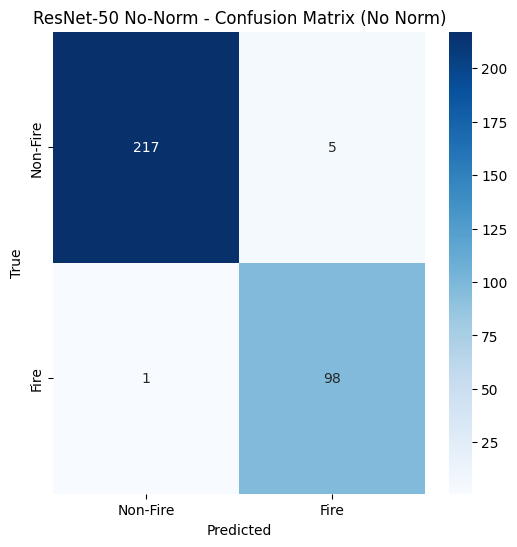

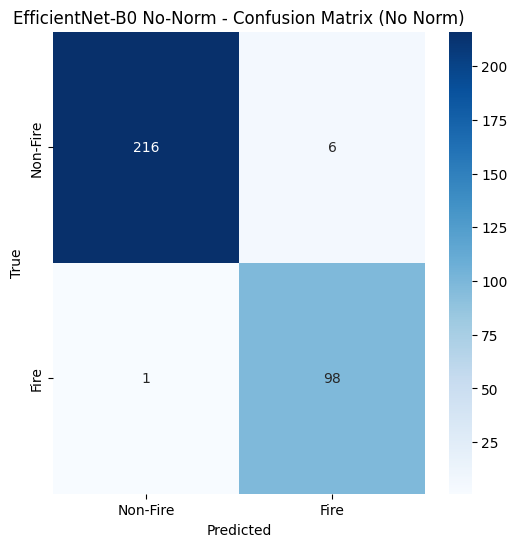

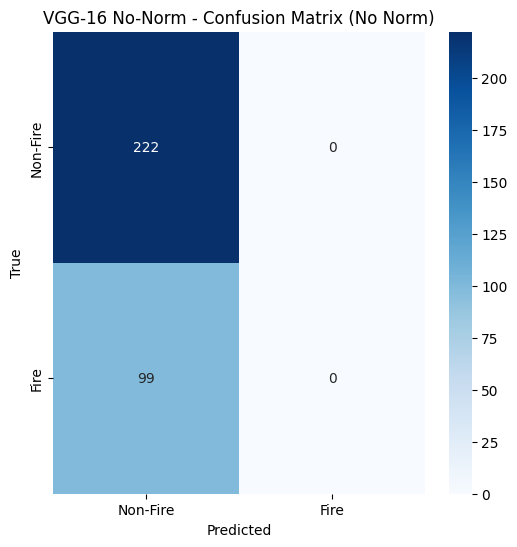

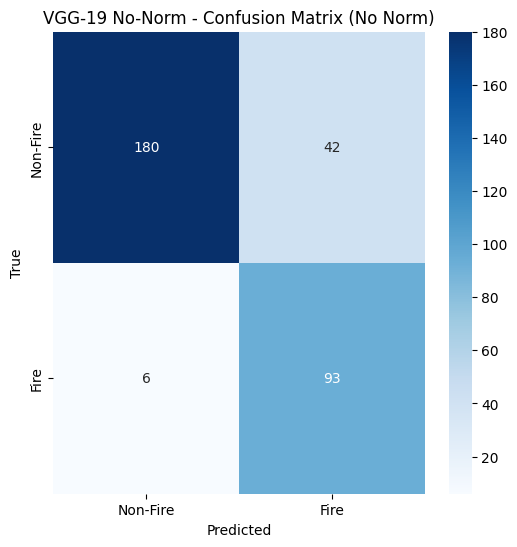

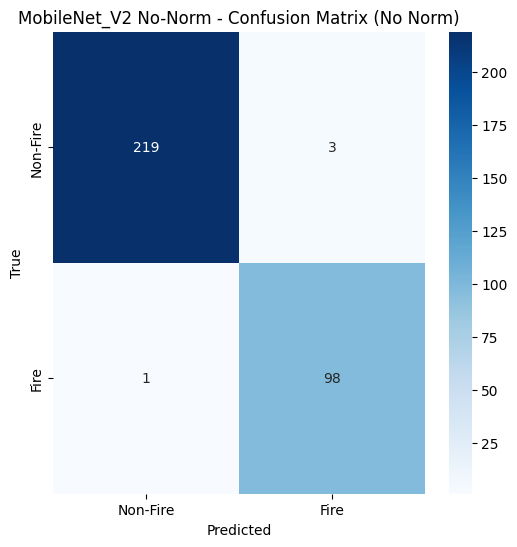

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_confusion_matrix_no_norm(model, test_loader_no_norm, model_name='Model'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader_no_norm:  # Use test loader without normalization
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Fire', 'Fire'], yticklabels=['Non-Fire', 'Fire'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} - Confusion Matrix (No Norm)')
    plt.show()

# Plot confusion matrices for No-Norm trained models
plot_confusion_matrix_no_norm(alexnet, test_loader_no_norm, model_name='AlexNet No-Norm')
plot_confusion_matrix_no_norm(resnet18, test_loader_no_norm, model_name='ResNet-18 No-Norm')
plot_confusion_matrix_no_norm(resnet50, test_loader_no_norm, model_name='ResNet-50 No-Norm')
plot_confusion_matrix_no_norm(efficientnet_b0, test_loader_no_norm, model_name='EfficientNet-B0 No-Norm')
plot_confusion_matrix_no_norm(vgg16, test_loader_no_norm, model_name='VGG-16 No-Norm')
plot_confusion_matrix_no_norm(vgg19, test_loader_no_norm, model_name='VGG-19 No-Norm')
plot_confusion_matrix_no_norm(mobilenet_v2, test_loader_no_norm, model_name='MobileNet_V2 No-Norm')


In [ ]:
from sklearn.metrics import classification_report
import torch

def generate_classification_report_no_norm(model, test_loader_no_norm, model_name='Model'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader_no_norm:  # Use test loader without normalization
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    print(f'{model_name} - Classification Report (No Norm):')
    print(classification_report(all_labels, all_preds, target_names=['Non-Fire', 'Fire']))

# Generate classification reports for No-Norm trained models
generate_classification_report_no_norm(alexnet, test_loader_no_norm, model_name='AlexNet No-Norm')
generate_classification_report_no_norm(resnet18, test_loader_no_norm, model_name='ResNet-18 No-Norm')
generate_classification_report_no_norm(resnet50, test_loader_no_norm, model_name='ResNet-50 No-Norm')
generate_classification_report_no_norm(efficientnet_b0, test_loader_no_norm, model_name='EfficientNet-B0 No-Norm')
generate_classification_report_no_norm(vgg16, test_loader_no_norm, model_name='VGG-16 No-Norm')
generate_classification_report_no_norm(vgg19, test_loader_no_norm, model_name='VGG-19 No-Norm')
generate_classification_report_no_norm(mobilenet_v2, test_loader_no_norm, model_name='MobileNet_V2 No-Norm')


AlexNet No-Norm - Classification Report (No Norm):
              precision    recall  f1-score   support

    Non-Fire       0.94      0.98      0.96       222
        Fire       0.94      0.85      0.89        99

    accuracy                           0.94       321
   macro avg       0.94      0.91      0.92       321
weighted avg       0.94      0.94      0.94       321

ResNet-18 No-Norm - Classification Report (No Norm):
              precision    recall  f1-score   support

    Non-Fire       0.99      0.98      0.98       222
        Fire       0.95      0.98      0.97        99

    accuracy                           0.98       321
   macro avg       0.97      0.98      0.97       321
weighted avg       0.98      0.98      0.98       321

ResNet-50 No-Norm - Classification Report (No Norm):
              precision    recall  f1-score   support

    Non-Fire       1.00      0.98      0.99       222
        Fire       0.95      0.99      0.97        99

    accuracy             

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np

# Define device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the model paths for No-Norm models
model_paths_no_norm = {
    "resnet18": "/content/drive/MyDrive/Splits/ResNet-18_NoNorm.pth",
    "resnet50": "/content/drive/MyDrive/Splits/ResNet-50_NoNorm.pth",
    "efficientnet_b0": "/content/drive/MyDrive/Splits/EfficientNet_B0_NoNorm.pth",
    "alexnet": "/content/drive/MyDrive/Splits/AlexNet_NoNorm.pth",
    "vgg16": "/content/drive/MyDrive/Splits/VGG-16_NoNorm.pth",
    "vgg19": "/content/drive/MyDrive/Splits/VGG-19_NoNorm.pth",
    "mobilenet_v2": "/content/drive/MyDrive/Splits/MobileNet_V2_NoNorm.pth"
}

# Function to initialize No-Norm models dynamically
def load_model_no_norm(model_name, path):
    model = getattr(models, model_name)(pretrained=False)

    # Modify classifier for binary classification
    if hasattr(model, "classifier"):  # For models like AlexNet, VGG, and EfficientNet
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 2)
    else:  # For ResNet and similar models
        model.fc = nn.Linear(model.fc.in_features, 2)

    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model

# Load all No-Norm trained models
loaded_models_no_norm = {name: load_model_no_norm(name, path) for name, path in model_paths_no_norm.items()}


In [ ]:
def get_model_outputs_no_norm(models, dataloader_no_norm):
    X, y = [], []

    with torch.no_grad():
        for inputs, labels in dataloader_no_norm:  # Use No-Norm dataloader
            inputs, labels = inputs.to(device), labels.to(device)
            model_preds = []

            for model in models.values():
                preds = torch.softmax(model(inputs), dim=1).cpu().numpy()
                model_preds.append(preds)

            combined_features = np.hstack(model_preds)  # Flatten predictions
            X.append(combined_features)
            y.append(labels.cpu().numpy())

    return np.vstack(X), np.hstack(y)

# Extract outputs from No-Norm models
X_no_norm, y_no_norm = get_model_outputs_no_norm(loaded_models_no_norm, test_loader_no_norm)


In [ ]:
# Get training data for No-Norm models
X_train_no_norm, y_train_no_norm = get_model_outputs_no_norm(loaded_models_no_norm, train_loader_no_norm)
X_val_no_norm, y_val_no_norm = get_model_outputs_no_norm(loaded_models_no_norm, val_loader_no_norm)

# Train meta-classifier (Logistic Regression)
meta_clf_no_norm = LogisticRegression()
meta_clf_no_norm.fit(X_train_no_norm, y_train_no_norm)

# Evaluate on validation set
y_pred_no_norm = meta_clf_no_norm.predict(X_val_no_norm)

# Print classification report
print("Meta-Ensemble Classification Report (No Norm):")
print(classification_report(y_val_no_norm, y_pred_no_norm))


Meta-Ensemble Classification Report (No Norm):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       163
           1       0.99      0.99      0.99        70

    accuracy                           0.99       233
   macro avg       0.99      0.99      0.99       233
weighted avg       0.99      0.99      0.99       233



In [ ]:
While you can't directly execute `git commit` within a Colab cell to an external repository, Colab has excellent integration with GitHub for version control. You can save your notebook directly to GitHub, which functions like a commit.

Here's how to save your Colab notebook to GitHub:

1.  **File -> Save a copy in GitHub...**
2.  A dialog box will appear. Select your GitHub **organization/user** and the **repository** where you want to save the notebook.
3.  You can choose to save it to a new branch, and provide a commit message.
4.  Click **OK** to save and commit your notebook to the selected GitHub repository.